<a href="https://colab.research.google.com/github/psheetalreddy/XAI-Based-Retinal-Disease-Classification-using-Fine-Tuned-ResNet50-with-Grad-CAM/blob/main/2_Explainability_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 3 & 4: Explainability Storage + Explanation Analysis
**Project:** Explainable Retinal Disease Classification with Systematic Explanation Analysis   

---
This notebook continues from `1_Model_Development_ResNet50_FineTuning_GradCAM.ipynb`.  

**Module 3:** Generate Grad-CAM for all test images → Store as structured CSV  
**Module 4:** Explanation Consistency + Stability Analysis + Visualization

## Step 0: Setup — Load Model & Dependencies

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr
from tqdm import tqdm

# ── Config ──────────────────────────────
IMG_SIZE       = 224
BATCH_SIZE     = 16
test_dir       = "/content/drive/MyDrive/Projects/Mini-project/eye-disease-dataset/test_dir"
LAST_CONV_LAYER = "conv5_block3_out"   # same layer used in Module 1/2
MODEL_PATH     = "/content/drive/MyDrive/Projects/Mini-project/phase2_best.keras"   # fine-tuned model from Module 2

# ── Load class mapping ───────────────────────────────────────────────────────
with open("/content/drive/MyDrive/Projects/Mini-project/eye-disease-dataset/cat_to_name.json", "r") as f:
    class_mapping = {int(k): v for k, v in json.load(f).items()}
# class_mapping: {1:'cataract', 2:'diabetic_retinopathy', 3:'glaucoma', 4:'normal'}

CLASS_NAMES = [class_mapping[i+1] for i in range(4)]   # 0-indexed list
print("Classes:", CLASS_NAMES)

# ── Load fine-tuned model ────────────────────────────────────────────────────
model = load_model(MODEL_PATH)
print("Model loaded Successfully")

Classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Model loaded Successfully


## Step 1: Rebuilding Test Generator (no shuffle)
Same settings as your existing notebook — shuffle=False is critical so image order is preserved.

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False       # ← must be False to align file paths with predictions
)
print(f"Test samples: {test_gen.samples} | Classes: {test_gen.class_indices}")

# Build full file-path list for Grad-CAM (we need the original image files)
file_paths = [os.path.join(test_dir, f) for f in test_gen.filenames]

Found 674 images belonging to 4 classes.
Test samples: 674 | Classes: {'1': 0, '2': 1, '3': 2, '4': 3}


---
# MODULE 3: Explainability & Explanation Storage
For every test image we:
1. Run prediction → get probability vector
2. Compute Grad-CAM heatmap (7×7 from `conv5_block3_out`)
3. Store everything in a structured DataFrame → saved as `explanation_store.csv`

In [4]:
# ── Grad-CAM helper (same logic as your existing make_gradcam_heatmap) ───────
def compute_gradcam(img_array, model, last_conv_layer_name):
    """
    Returns a normalised 7x7 Grad-CAM heatmap (numpy float32).
    img_array: preprocessed image, shape (1, 224, 224, 3)
    """
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        predicted_index = tf.argmax(predictions[0])
        loss = predictions[:, predicted_index]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.math.reduce_max(heatmap)
    if max_val > 0:
        heatmap = heatmap / max_val
    return heatmap.numpy()   # shape (7, 7)

In [5]:
# ── Build Explanation Store ───────────────────────────────────────────────────
# This loops over all test images, runs inference + Grad-CAM, stores results.
# Runtime: ~10-20 min on Colab CPU; much faster on GPU.

records = []
true_labels = test_gen.classes           # shape (N,)
n_samples   = test_gen.samples

# Get all predictions in one batch pass (faster)
test_gen.reset()
all_probs = model.predict(test_gen, verbose=1)   # shape (N, 4)

print("\nGenerating Grad-CAM for all test images...")
for idx in tqdm(range(n_samples)):
    img_path  = file_paths[idx]
    true_lbl  = int(true_labels[idx])
    probs     = all_probs[idx]                    # (4,)
    pred_lbl  = int(np.argmax(probs))

    # Load & preprocess individual image for Grad-CAM
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    heatmap = compute_gradcam(img_array, model, LAST_CONV_LAYER)  # (7,7)

    records.append({
        "image_id"       : idx,
        "file_path"      : img_path,
        "true_label"     : true_lbl,
        "true_class"     : CLASS_NAMES[true_lbl],
        "predicted_label": pred_lbl,
        "predicted_class": CLASS_NAMES[pred_lbl],
        "correct"        : int(true_lbl == pred_lbl),
        "prob_cataract"  : float(probs[0]),
        "prob_dr"        : float(probs[1]),
        "prob_glaucoma"  : float(probs[2]),
        "prob_normal"    : float(probs[3]),
        "confidence"     : float(np.max(probs)),
        # Flatten 7x7 heatmap → 49 values stored as JSON string
        "gradcam_heatmap": json.dumps(heatmap.flatten().tolist())
    })

df = pd.DataFrame(records)
df.to_csv("explanation_store.csv", index=False)
print(f"\nSaved explanation_store.csv  →  {len(df)} rows")
df.head()

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


43/43 ━━━━━━━━━━━━━━━━━━━━ 200s 5s/step

Generating Grad-CAM for all test images...


  0%|          | 0/674 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
100%|██████████| 674/674 [13:54<00:00,  1.24s/it]


Saved explanation_store.csv  →  674 rows


,image_id,file_path,true_label,true_class,predicted_label,predicted_class,correct,prob_cataract,prob_dr,prob_glaucoma,prob_normal,confidence,gradcam_heatmap
0,0,/content/drive/MyDrive/Projects/Mini-project/e...,0,cataract,0,cataract,1,0.866100,0.000080,0.002135,0.131685,0.866100,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1651941537857..."
1,1,/content/drive/MyDrive/Projects/Mini-project/e...,0,cataract,3,normal,0,0.001604,0.000074,0.000584,0.997738,0.997738,"[0.6756536364555359, 0.6902379393577576, 0.290..."
2,2,/content/drive/MyDrive/Projects/Mini-project/e...,0,cataract,0,cataract,1,0.998321,0.000016,0.000006,0.001657,0.998321,"[0.0, 0.0, 0.0, 0.05944741517305374, 0.0054444..."
3,3,/content/drive/MyDrive/Projects/Mini-project/e...,0,cataract,3,normal,0,0.000770,0.001037,0.001158,0.997036,0.997036,"[0.8440548777580261, 0.6118108034133911, 0.080..."
4,4,/content/drive/MyDrive/Projects/Mini-project/e...,0,cataract,0,cataract,1,0.893617,0.005222,0.003850,0.097311,0.893617,"[0.0, 0.0, 0.0, 0.0, 0.3768487870693207, 0.856..."


In [6]:
# Quick sanity check
print("Overall accuracy from store:", df['correct'].mean().round(4))
print("\nPer-class sample counts:")
print(df.groupby('true_class')['correct'].agg(['count','mean']).rename(columns={'mean':'accuracy'}))

Overall accuracy from store: 0.8961

Per-class sample counts:
                      count  accuracy
true_class                           
cataract                166  0.909639
diabetic_retinopathy    175  0.948571
glaucoma                161  0.788820
normal                  172  0.930233


---
# MODULE 4: Explanation Analysis & Visualization

Three analyses:
1. **Explanation Consistency** — how similar are Grad-CAM heatmaps within the same disease class?
2. **Explanation Stability** — how robust are heatmaps to small input noise?
3. **Visualization** — average attention maps, correct vs incorrect comparison, per-sample overlays

## 4.1 Explanation Consistency Analysis
For each class, compute pairwise cosine similarity of all Grad-CAM heatmap vectors (flattened 7×7 = 49-dim).  
**High consistency** → the model reliably attends to the same retinal regions for a given disease.

In [7]:
# ── Load stored heatmaps ─────────────────────────────────────────────────────
df = pd.read_csv("explanation_store.csv")
df['heatmap_vector'] = df['gradcam_heatmap'].apply(lambda x: np.array(json.loads(x)))

consistency_results = {}

for class_name in CLASS_NAMES:
    # Use only CORRECTLY classified samples for consistency
    class_df = df[(df['true_class'] == class_name) & (df['correct'] == 1)]
    if len(class_df) < 2:
        print(f"  Skipping {class_name}: not enough correct samples")
        continue

    heatmaps = np.stack(class_df['heatmap_vector'].values)   # (N, 49)
    sim_matrix = cosine_similarity(heatmaps)                  # (N, N)

    # Extract upper triangle (exclude self-similarity on diagonal)
    upper_idx = np.triu_indices_from(sim_matrix, k=1)
    pairwise_sims = sim_matrix[upper_idx]

    consistency_results[class_name] = {
        'n_samples'      : len(class_df),
        'mean_similarity': float(pairwise_sims.mean()),
        'std_similarity' : float(pairwise_sims.std()),
        'min_similarity' : float(pairwise_sims.min()),
        'max_similarity' : float(pairwise_sims.max()),
    }
    print(f"  {class_name:25s} | n={len(class_df):4d} | "
          f"mean_sim={pairwise_sims.mean():.4f} ± {pairwise_sims.std():.4f}")

consistency_df = pd.DataFrame(consistency_results).T
print("\nConsistency Summary:")
print(consistency_df.round(4))

  cataract                  | n= 151 | mean_sim=0.5565 ± 0.1995
  diabetic_retinopathy      | n= 166 | mean_sim=0.4349 ± 0.2288
  glaucoma                  | n= 127 | mean_sim=0.4606 ± 0.2370
  normal                    | n= 160 | mean_sim=0.7016 ± 0.1103

Consistency Summary:
                      n_samples  mean_similarity  std_similarity  \
cataract                  151.0           0.5565          0.1995   
diabetic_retinopathy      166.0           0.4349          0.2288   
glaucoma                  127.0           0.4606          0.2370   
normal                    160.0           0.7016          0.1103   

                      min_similarity  max_similarity  
cataract                      0.0045          0.9725  
diabetic_retinopathy          0.0000          0.9511  
glaucoma                      0.0000          0.9709  
normal                        0.2715          0.9472  


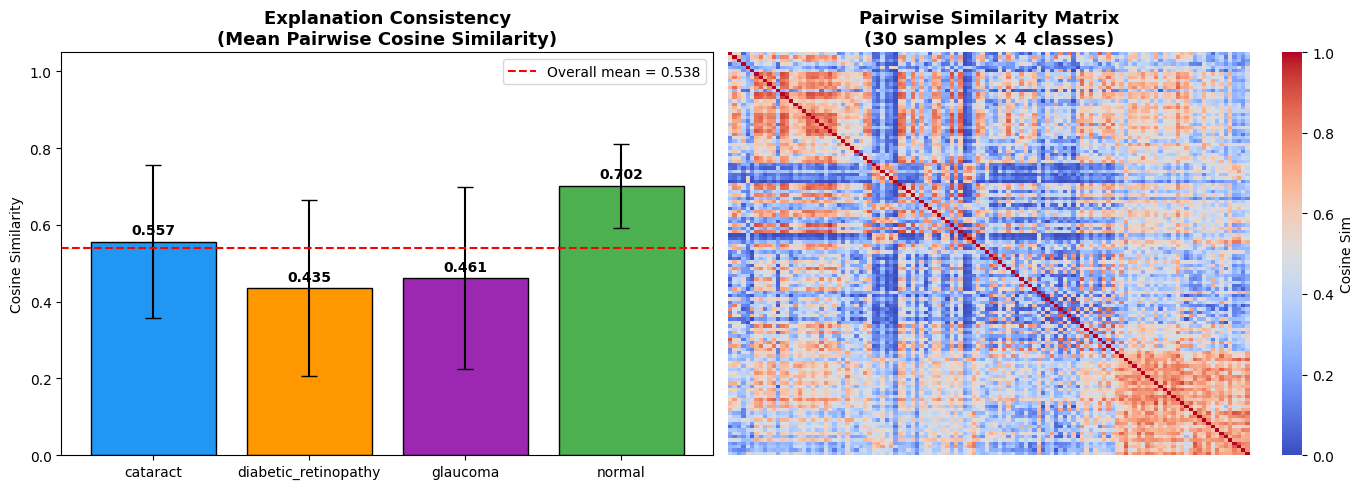

Saved: consistency_analysis.png


In [8]:
# ── Visualise Consistency Scores ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: mean similarity per class
ax = axes[0]
colors = ['#2196F3','#FF9800','#9C27B0','#4CAF50']
bars = ax.bar(consistency_df.index,
              consistency_df['mean_similarity'],
              yerr=consistency_df['std_similarity'],
              color=colors, edgecolor='black', capsize=6)
ax.set_title('Explanation Consistency\n(Mean Pairwise Cosine Similarity)', fontsize=13, fontweight='bold')
ax.set_ylabel('Cosine Similarity')
ax.set_ylim(0, 1.05)
ax.axhline(y=consistency_df['mean_similarity'].mean(), color='red',
           linestyle='--', label=f"Overall mean = {consistency_df['mean_similarity'].mean():.3f}")
ax.legend()
for bar, val in zip(bars, consistency_df['mean_similarity']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

# Heatmap of per-class similarity matrix (first 30 samples each)
ax2 = axes[1]
combined = []
labels_for_heatmap = []
for i, cn in enumerate(CLASS_NAMES):
    vecs = np.stack(df[(df['true_class']==cn) & (df['correct']==1)]['heatmap_vector'].values[:30])
    combined.append(vecs)
    labels_for_heatmap.extend([cn[:3].upper()]*len(vecs))
combined = np.vstack(combined)
sim_full = cosine_similarity(combined)
sns.heatmap(sim_full, ax=ax2, cmap='coolwarm', vmin=0, vmax=1,
            xticklabels=False, yticklabels=False, cbar_kws={'label': 'Cosine Sim'})
ax2.set_title('Pairwise Similarity Matrix\n(30 samples × 4 classes)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('consistency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: consistency_analysis.png")

## 4.2 Explanation Stability Analysis
For a sample of images (n=20 per class), we add Gaussian noise at increasing levels (σ = 0.01, 0.03, 0.05, 0.10) and measure how much the Grad-CAM heatmap changes.  
**High stability** → explanations do not change drastically with small input variations.

In [ ]:
NOISE_LEVELS  = [0.01, 0.03, 0.05, 0.10]   # std of Gaussian noise
N_PERTURB     = 5       # perturbations per noise level per image
SAMPLES_PER_CLASS = 20  # images to test per class

stability_results = {}   # class → {noise_level → [similarities]}

for class_name in CLASS_NAMES:
    class_df = df[(df['true_class'] == class_name) & (df['correct'] == 1)].head(SAMPLES_PER_CLASS)
    noise_sims = {nl: [] for nl in NOISE_LEVELS}

    for _, row in tqdm(class_df.iterrows(), total=len(class_df),
                       desc=f"Stability [{class_name}]"):
        img = tf.keras.preprocessing.image.load_img(
            row['file_path'], target_size=(IMG_SIZE, IMG_SIZE))
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)    # (1,224,224,3)

        # Original heatmap
        orig_heatmap = compute_gradcam(img_array, model, LAST_CONV_LAYER).flatten()

        for nl in NOISE_LEVELS:
            sims_for_level = []
            for _ in range(N_PERTURB):
                noise = np.random.normal(0, nl, img_array.shape).astype(np.float32)
                perturbed = img_array + noise
                pert_heatmap = compute_gradcam(perturbed, model, LAST_CONV_LAYER).flatten()
                # Cosine similarity between original and perturbed heatmap
                sim = cosine_similarity([orig_heatmap], [pert_heatmap])[0][0]
                sims_for_level.append(sim)
            noise_sims[nl].append(np.mean(sims_for_level))

    stability_results[class_name] = {nl: np.mean(v) for nl, v in noise_sims.items()}

# Build a summary dataframe
stability_df = pd.DataFrame(stability_results).T    # rows=classes, cols=noise_levels
stability_df.columns = [f"noise={c}" for c in stability_df.columns]
print("\nStability Summary (mean cosine similarity under perturbation):")
print(stability_df.round(4))

In [16]:
# Build a summary dataframe
stability_df = pd.DataFrame(stability_results).T    # rows=classes, cols=noise_levels
stability_df.columns = [f"noise={c}" for c in stability_df.columns]
print("\nStability Summary (mean cosine similarity under perturbation):")
print(stability_df.round(4))


Stability Summary (mean cosine similarity under perturbation):
                      noise=0.01  noise=0.03  noise=0.05  noise=0.1
cataract                  0.9992      0.9989      0.9984     0.9969
diabetic_retinopathy      1.0000      0.9995      0.9992     0.9986
glaucoma                  0.9999      0.9996      0.9988     0.9970
normal                    0.9998      0.9996      0.9993     0.9990


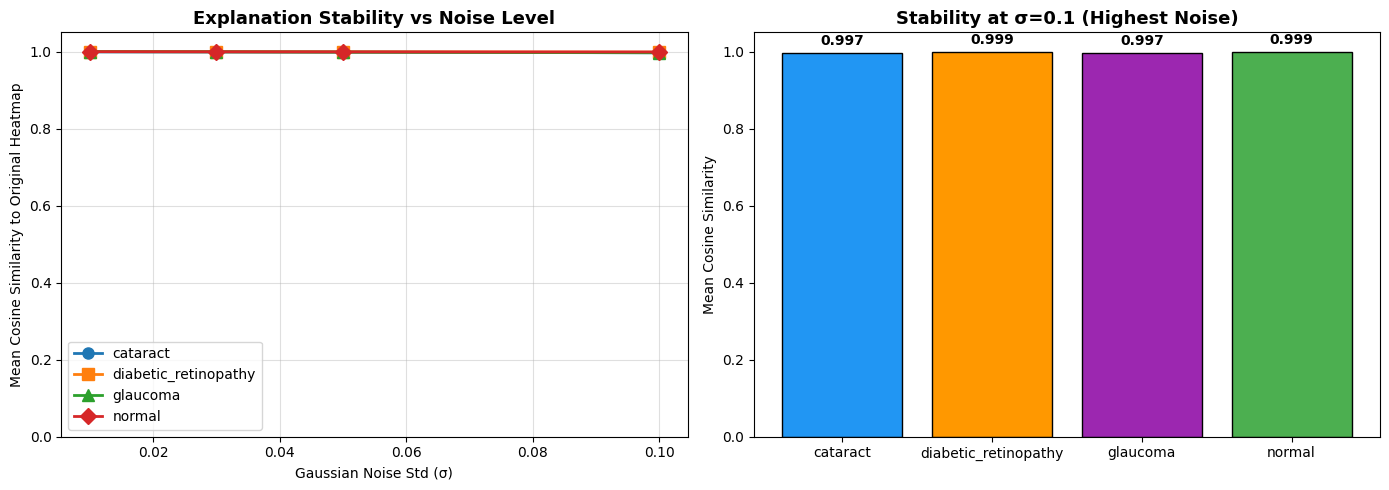

Saved: stability_analysis.png


In [10]:
# ── Visualise Stability ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line plot: stability vs noise level
ax = axes[0]
markers = ['o','s','^','D']
for i, cn in enumerate(CLASS_NAMES):
    y_vals = [stability_results[cn][nl] for nl in NOISE_LEVELS]
    ax.plot(NOISE_LEVELS, y_vals, marker=markers[i], label=cn, linewidth=2, markersize=8)
ax.set_title('Explanation Stability vs Noise Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Gaussian Noise Std (σ)')
ax.set_ylabel('Mean Cosine Similarity to Original Heatmap')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.4)

# Grouped bar chart at highest noise level
ax2 = axes[1]
high_noise = NOISE_LEVELS[-1]
vals = [stability_results[cn][high_noise] for cn in CLASS_NAMES]
bars = ax2.bar(CLASS_NAMES, vals, color=colors, edgecolor='black')
ax2.set_title(f'Stability at σ={high_noise} (Highest Noise)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Mean Cosine Similarity')
ax2.set_ylim(0, 1.05)
for bar, v in zip(bars, vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('stability_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: stability_analysis.png")

## 4.3 Average Attention Maps Per Disease Class
Average all Grad-CAM heatmaps within each class to reveal what retinal regions the model consistently focuses on.

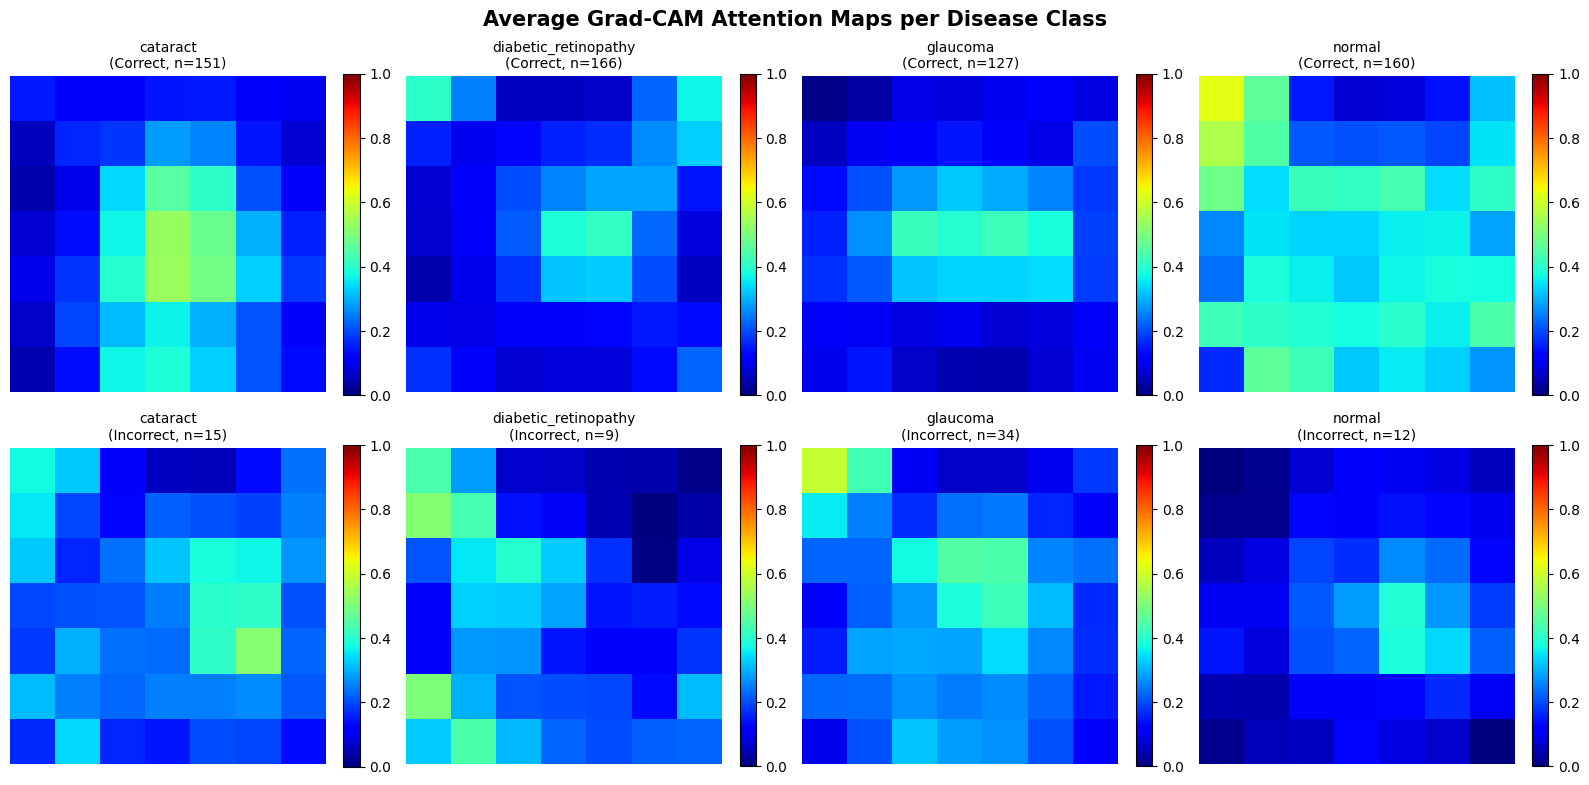

Saved: average_attention_maps.png


In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Average Grad-CAM Attention Maps per Disease Class', fontsize=15, fontweight='bold')

for col, class_name in enumerate(CLASS_NAMES):
    # ── Correct predictions ──────────────────────────────────────────────────
    correct_vecs = np.stack(
        df[(df['true_class']==class_name) & (df['correct']==1)]['heatmap_vector'].values
    )  # (N, 49)
    avg_correct = correct_vecs.mean(axis=0).reshape(7, 7)

    # ── Incorrect predictions ────────────────────────────────────────────────
    wrong_df = df[(df['true_class']==class_name) & (df['correct']==0)]
    if len(wrong_df) > 0:
        wrong_vecs = np.stack(wrong_df['heatmap_vector'].values)
        avg_wrong  = wrong_vecs.mean(axis=0).reshape(7, 7)
    else:
        avg_wrong = np.zeros((7, 7))

    # Plot correct (top row)
    im0 = axes[0, col].imshow(avg_correct, cmap='jet', vmin=0, vmax=1)
    axes[0, col].set_title(f'{class_name}\n(Correct, n={len(correct_vecs)})', fontsize=10)
    axes[0, col].axis('off')
    plt.colorbar(im0, ax=axes[0, col], fraction=0.046)

    # Plot incorrect (bottom row)
    im1 = axes[1, col].imshow(avg_wrong, cmap='jet', vmin=0, vmax=1)
    axes[1, col].set_title(f'{class_name}\n(Incorrect, n={len(wrong_df)})', fontsize=10)
    axes[1, col].axis('off')
    plt.colorbar(im1, ax=axes[1, col], fraction=0.046)

axes[0, 0].set_ylabel('Correct Predictions', fontsize=11)
axes[1, 0].set_ylabel('Incorrect Predictions', fontsize=11)

plt.tight_layout()
plt.savefig('average_attention_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: average_attention_maps.png")

## 4.4 Confidence vs. Consistency Correlation
Does higher prediction confidence correlate with more consistent (reliable) explanations?

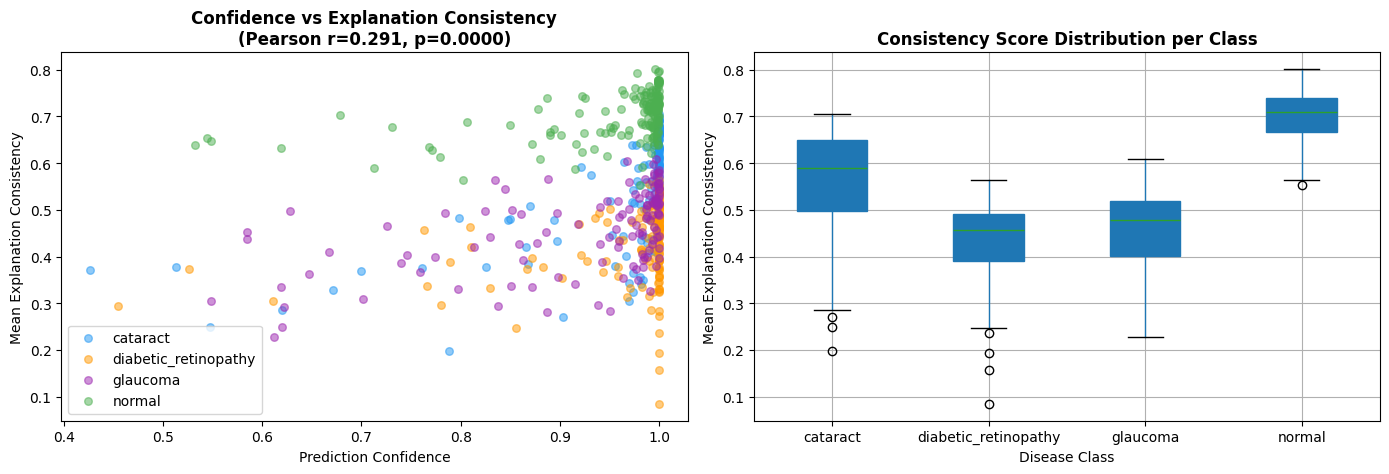

Pearson correlation: r=0.2911, p=0.0000
Saved: confidence_vs_consistency.png


In [12]:
# For each correct sample, compute its average similarity to other same-class samples
# (a proxy for how consistent that individual explanation is)

per_sample_consistency = []

for class_name in CLASS_NAMES:
    class_df = df[(df['true_class']==class_name) & (df['correct']==1)].copy()
    if len(class_df) < 2:
        continue
    heatmaps = np.stack(class_df['heatmap_vector'].values)
    sim_matrix = cosine_similarity(heatmaps)
    # Mean similarity of each sample to the rest (exclude self)
    np.fill_diagonal(sim_matrix, np.nan)
    mean_sims = np.nanmean(sim_matrix, axis=1)
    class_df = class_df.copy()
    class_df['mean_consistency'] = mean_sims
    per_sample_consistency.append(class_df[['confidence', 'mean_consistency', 'true_class']])

corr_df = pd.concat(per_sample_consistency, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax = axes[0]
for i, cn in enumerate(CLASS_NAMES):
    sub = corr_df[corr_df['true_class']==cn]
    ax.scatter(sub['confidence'], sub['mean_consistency'],
               label=cn, alpha=0.5, s=30, color=colors[i])
r, p = pearsonr(corr_df['confidence'], corr_df['mean_consistency'])
ax.set_xlabel('Prediction Confidence')
ax.set_ylabel('Mean Explanation Consistency')
ax.set_title(f'Confidence vs Explanation Consistency\n(Pearson r={r:.3f}, p={p:.4f})',
             fontsize=12, fontweight='bold')
ax.legend()

# Box plot of consistency per class
ax2 = axes[1]
corr_df.boxplot(column='mean_consistency', by='true_class', ax=ax2,
                patch_artist=True)
ax2.set_title('Consistency Score Distribution per Class', fontsize=12, fontweight='bold')
ax2.set_xlabel('Disease Class')
ax2.set_ylabel('Mean Explanation Consistency')
plt.suptitle('')

plt.tight_layout()
plt.savefig('confidence_vs_consistency.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Pearson correlation: r={r:.4f}, p={p:.4f}")
print("Saved: confidence_vs_consistency.png")

## 4.5 Final Summary Report
Print a clean summary table of all explanation analysis results.

In [13]:
print("=" * 65)
print("   EXPLANATION ANALYSIS SUMMARY REPORT")
print("=" * 65)
print(f"   Model : {MODEL_PATH}")
print(f"   Test samples : {len(df)}")
print(f"   Overall accuracy : {df['correct'].mean():.4f}")
print()
print("── CONSISTENCY (pairwise cosine similarity of heatmaps) ──")
print(consistency_df[['n_samples','mean_similarity','std_similarity']].round(4).to_string())
print()
print("── STABILITY (similarity under Gaussian noise) ──")
print(stability_df.round(4).to_string())
print()
print(f"── CONFIDENCE vs CONSISTENCY ──")
print(f"   Pearson r = {r:.4f}  |  p-value = {p:.4f}")
if r > 0.3 and p < 0.05:
    print("   ✓ Higher confidence predictions have more consistent explanations.")
elif p >= 0.05:
    print("   ~ No statistically significant correlation found.")
else:
    print("   ✗ Confidence and explanation consistency are weakly correlated.")
print("=" * 65)

   EXPLANATION ANALYSIS SUMMARY REPORT
   Model : /content/drive/MyDrive/Projects/Mini-project/phase2_best.keras
   Test samples : 674
   Overall accuracy : 0.8961

── CONSISTENCY (pairwise cosine similarity of heatmaps) ──
                      n_samples  mean_similarity  std_similarity
cataract                  151.0           0.5565          0.1995
diabetic_retinopathy      166.0           0.4349          0.2288
glaucoma                  127.0           0.4606          0.2370
normal                    160.0           0.7016          0.1103

── STABILITY (similarity under Gaussian noise) ──
                      noise=0.01  noise=0.03  noise=0.05  noise=0.1
cataract                  0.9992      0.9989      0.9984     0.9969
diabetic_retinopathy      1.0000      0.9995      0.9992     0.9986
glaucoma                  0.9999      0.9996      0.9988     0.9970
normal                    0.9998      0.9996      0.9993     0.9990

── CONFIDENCE vs CONSISTENCY ──
   Pearson r = 0.2911  |  p

In [14]:
# Save all summary data to CSV for use in your final report
consistency_df.to_csv('consistency_summary.csv')
stability_df.to_csv('stability_summary.csv')
print("Saved: consistency_summary.csv, stability_summary.csv")
print("\nAll outputs generated:")
print("  explanation_store.csv       ← structured prediction + heatmap database")
print("  consistency_analysis.png    ← Module 4.1 visualization")
print("  stability_analysis.png      ← Module 4.2 visualization")
print("  average_attention_maps.png  ← Module 4.3 visualization")
print("  confidence_vs_consistency.png ← Module 4.4 visualization")
print("  consistency_summary.csv     ← table for report")
print("  stability_summary.csv       ← table for report")

Saved: consistency_summary.csv, stability_summary.csv

All outputs generated:
  explanation_store.csv       ← structured prediction + heatmap database
  consistency_analysis.png    ← Module 4.1 visualization
  stability_analysis.png      ← Module 4.2 visualization
  average_attention_maps.png  ← Module 4.3 visualization
  confidence_vs_consistency.png ← Module 4.4 visualization
  consistency_summary.csv     ← table for report
  stability_summary.csv       ← table for report
